# Three Baseline Classifiers on full images
This notebook trains the first three **full-image + metadata** classifiers:

1. **Sagittal T2/STIR** → Spinal Canal Stenosis  
2. **Sagittal T1** → Neural Foraminal Narrowing  
3. **Axial T2** → Subarticular Stenosis  

The input format is corrected for MRI:
- DICOM grayscale is loaded directly from `img_path`.
- Intensities are clipped using percentiles and normalized to `[0, 1]`.
- The grayscale image is repeated into **3 identical channels** for ImageNet-compatible CNNs.
- Mean and standard deviation are computed from the **training data only**, not reused from another dataset.
- ResNet34 can be trained either with ImageNet-pretrained weights or from scratch.

## 1. Imports

In [2]:
# IMPORTS
import os
import re
import copy
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
import pydicom
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    log_loss,
)

from tqdm.auto import tqdm

## 2. Reproducibility and configuration

In [3]:
# SET SEED FOR REPRODUCIBILITY
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)

In [4]:
# ----------------------------
# CONFIG
# ----------------------------
import os

ROOT = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification")
DATA_ROOT = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data")
PROJECT_ROOT = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Classification-baseline")
DATA_CSV = DATA_ROOT / "data-rsna2024" / "data_merged.csv"
os.chdir(ROOT)

# Output folder for trained models and results.
MODEL_ROOT_DIR = Path("models")
RUN_NAME = "models_baseline_three_class_medical_oriented"

OUTPUT_DIR = MODEL_ROOT_DIR / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Transfer learning is recommended for this limited medical-imaging setup.
PRETRAINED = True

IMAGE_SIZE = 224
BATCH_SIZE = 32

# Early stopping is allowed only after MIN_EPOCHS.
# These values are less aggressive than recall-only stopping.
EPOCHS = 50
MIN_EPOCHS = 15
PATIENCE = 10
MIN_DELTA = 1e-4

LR = 1e-4
BACKBONE_LR_MULTIPLIER = 0.1
WEIGHT_DECAY = 1e-4

# DataLoader performance settings.
# Keep NUM_WORKERS > 0 for speed. persistent_workers reduces repeated worker cleanup.
NUM_WORKERS = 4
PIN_MEMORY = True
PERSISTENT_WORKERS = True
PREFETCH_FACTOR = 2

# Model-head regularization.
HIDDEN_DIM = 512
DROPOUT = 0.15

# Class imbalance and medical-priority controls.
# The base class weights are inverse-frequency weights from the training split.
# Moderate and severe classes can receive an extra multiplier because false negatives
# are more costly in this medical task, especially for severe cases.
MODERATE_WEIGHT_MULTIPLIER = 1.1
SEVERE_WEIGHT_MULTIPLIER = 1.3
USE_WEIGHTED_SAMPLER = False
LABEL_SMOOTHING = 0.0
GRAD_CLIP_NORM = 1.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def dataloader_worker_kwargs(num_workers=NUM_WORKERS):
    """Return DataLoader worker-related kwargs that are valid for the chosen num_workers."""
    kwargs = {
        "num_workers": num_workers,
        "pin_memory": PIN_MEMORY,
    }

    if num_workers > 0:
        kwargs["persistent_workers"] = PERSISTENT_WORKERS
        kwargs["prefetch_factor"] = PREFETCH_FACTOR

    return kwargs


print("Using device:", DEVICE)
print("Project root:", PROJECT_ROOT)
print("Data CSV:", DATA_CSV)
print("Output dir:", OUTPUT_DIR)
print("NUM_WORKERS:", NUM_WORKERS)


Using device: cuda
Project root: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Classification-baseline
Data CSV: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data/data-rsna2024/data_merged.csv
Output dir: models/models_baseline_three_class_medical_oriented
NUM_WORKERS: 4


## 3. Load and prepare dataframe

This section creates:

- `base_condition`: condition without left/right prefix
- `side`: `center`, `left`, or `right`
- `target`: severity encoded as `0`, `1`, `2`

For the first full-image classifiers, coordinates `x` and `y` are not used.

In [5]:
# LABEL DEFINITIONS
data_merged = pd.read_csv(DATA_CSV)

SEVERITY_MAP = {
    "Normal/Mild": 0,
    "Moderate": 1,
    "Severe": 2,
}

TARGET_NAMES = ["Normal/Mild", "Moderate", "Severe"]
N_CLASSES = len(TARGET_NAMES)

LEVELS = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]

SIDE_TO_ID = {
    "center": 0,
    "left": 1,
    "right": 2,
}

SERIES_TO_ID = {
    "Sagittal T2/STIR": 0,
    "Sagittal T1": 1,
    "Axial T2": 2,
}

LEVEL_TO_ID = {level: idx for idx, level in enumerate(LEVELS)}


def extract_side(condition):
    condition = str(condition).lower()

    if condition.startswith("left"):
        return "left"
    elif condition.startswith("right"):
        return "right"
    else:
        return "center"


def extract_base_condition(condition):
    condition = str(condition)
    return (
        condition
        .replace("Left ", "")
        .replace("Right ", "")
    )

data_merged["side"] = data_merged["condition"].apply(extract_side)
data_merged["base_condition"] = data_merged["condition"].apply(extract_base_condition)
data_merged["target"] = data_merged["severity"].map(SEVERITY_MAP)


data_merged = data_merged.dropna(subset=[
    "study_id",
    "img_path",
    "target",
    "level",
    "side",
    "series_description",
]).copy()

data_merged["target"] = data_merged["target"].astype(int)
print(data_merged["base_condition"].value_counts())
print("==========================")
print(data_merged["series_description"].value_counts())
#display(data_merged.head())

base_condition
Neural Foraminal Narrowing    19689
Subarticular Stenosis         19215
Spinal Canal Stenosis          9753
Name: count, dtype: int64
series_description
Sagittal T1         19694
Axial T2            19215
Sagittal T2/STIR     9748
Name: count, dtype: int64


## 4. Study-level train/validation/test split
Split is created by `study_id`, which prevents patient/study leakage.

In [6]:
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42

# First split: train vs temporary validation + test
gss1 = GroupShuffleSplit(
    n_splits=1,
    train_size=TRAIN_SIZE,
    random_state=RANDOM_STATE,
)

train_idx, temp_idx = next(
    gss1.split(
        data_merged,
        groups=data_merged["study_id"],
    )
)

train_df = data_merged.iloc[train_idx].copy()
temp_df = data_merged.iloc[temp_idx].copy()

# Second split: validation vs test from the temporary set
val_relative_size = VAL_SIZE / (VAL_SIZE + TEST_SIZE)

gss2 = GroupShuffleSplit(
    n_splits=1,
    train_size=val_relative_size,
    random_state=RANDOM_STATE,
)

val_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df["study_id"],
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Rows:")
print("train:", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)

print("\nUnique studies:")
print("train:", train_df["study_id"].nunique())
print("val:  ", val_df["study_id"].nunique())
print("test: ", test_df["study_id"].nunique())

Rows:
train: (34045, 14)
val:   (7289, 14)
test:  (7323, 14)

Unique studies:
train: 1381
val:   296
test:  297


In [7]:
# Cell 1: prepare merged dataframe
plot_df = pd.concat(
    [
        train_df[["condition", "base_condition", "severity"]].assign(split="train"),
        val_df[["condition", "base_condition", "severity"]].assign(split="val"),
        test_df[["condition", "base_condition", "severity"]].assign(split="test"),
    ],
    ignore_index=True,
)

plot_df["condition_plot"] = plot_df["base_condition"]

plot_df.loc[
    plot_df["condition"].str.contains("Left Neural Foraminal Narrowing", na=False),
    "condition_plot"
] = "Left Neural Foraminal Narrowing"

plot_df.loc[
    plot_df["condition"].str.contains("Right Neural Foraminal Narrowing", na=False),
    "condition_plot"
] = "Right Neural Foraminal Narrowing"

severity_order = ["Normal/Mild", "Moderate", "Severe"]
split_order = ["train", "val", "test"]

plot_df["severity"] = pd.Categorical(plot_df["severity"], categories=severity_order, ordered=True)
plot_df["split"] = pd.Categorical(plot_df["split"], categories=split_order, ordered=True)

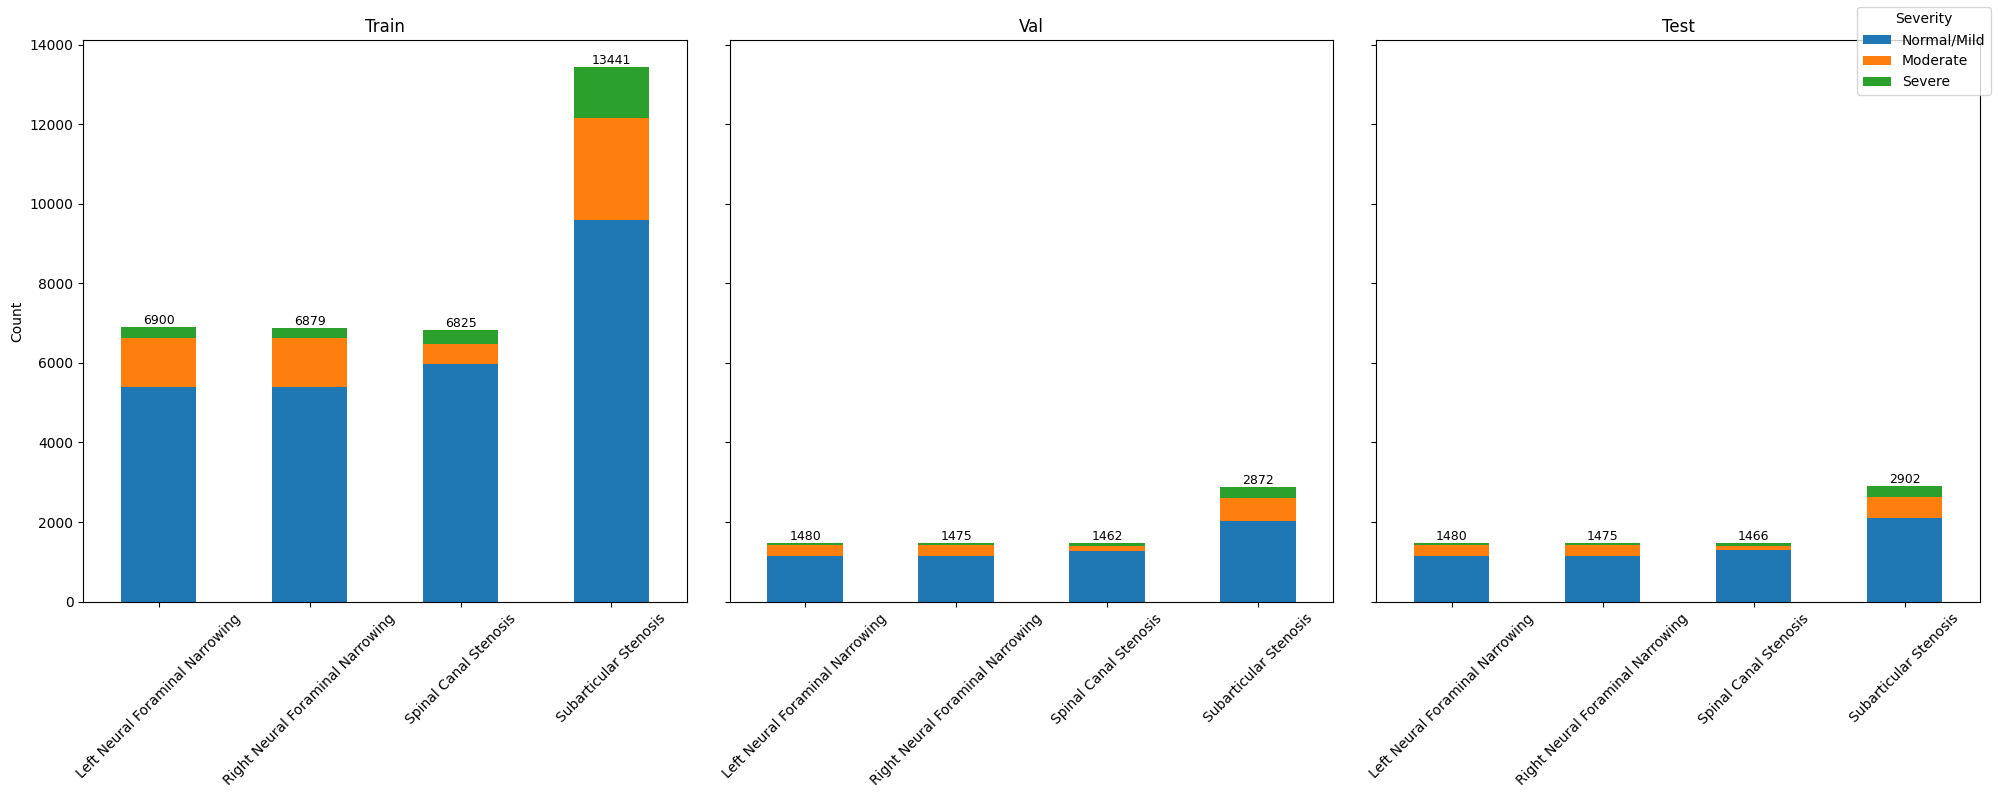

In [8]:
# Cell 2: side-by-side stacked bar charts with total counts

import matplotlib.pyplot as plt

condition_order = sorted(plot_df["condition_plot"].dropna().unique())

fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)

for ax, split in zip(axes, split_order):
    split_counts = pd.crosstab(
        plot_df.loc[plot_df["split"] == split, "condition_plot"],
        plot_df.loc[plot_df["split"] == split, "severity"]
    ).reindex(index=condition_order, columns=severity_order, fill_value=0)

    split_counts.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        legend=False
    )

    totals = split_counts.sum(axis=1)

    for i, total in enumerate(totals):
        ax.text(
            i,
            total,
            str(int(total)),
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(f"{split.capitalize()}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Count")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Severity", loc="upper right")

plt.tight_layout()
plt.show()

## 5. Define the three classifiers

Each model is trained on the matching sequence and condition.

In [9]:
MODEL_CONFIGS = {
    "spinal_canal_stenosis": {
        "base_condition": "Spinal Canal Stenosis",
        "series_description": "Sagittal T2/STIR",
    },
    "neural_foraminal_narrowing": {
        "base_condition": "Neural Foraminal Narrowing",
        "series_description": "Sagittal T1",
    },
    "subarticular_stenosis": {
        "base_condition": "Subarticular Stenosis",
        "series_description": "Axial T2",
    },
}


def make_model_df(df, base_condition, series_description):
    out = df[
        (df["base_condition"] == base_condition) &
        (df["series_description"] == series_description)
    ].copy()

    out = out.dropna(subset=[
        "img_path",
        "target",
        "level",
        "side",
        "series_description",
    ])

    return out.reset_index(drop=True)


model_dfs = {}

for model_name, cfg in MODEL_CONFIGS.items():
    model_dfs[model_name] = {
        "train": make_model_df(train_df, cfg["base_condition"], cfg["series_description"]),
        "val": make_model_df(val_df, cfg["base_condition"], cfg["series_description"]),
        "test": make_model_df(test_df, cfg["base_condition"], cfg["series_description"]),
    }

for model_name, parts in model_dfs.items():
    print("\n", model_name)
    for split_name, split_df in parts.items():
        print(f"{split_name:5s}: {len(split_df):6d} rows | {split_df['study_id'].nunique():4d} studies")
        print(split_df["target"].value_counts().sort_index().rename(index=dict(enumerate(TARGET_NAMES))))


 spinal_canal_stenosis
train:   6820 rows | 1380 studies
target
Normal/Mild    5964
Moderate        513
Severe          343
Name: count, dtype: int64
val  :   1462 rows |  296 studies
target
Normal/Mild    1282
Moderate        117
Severe           63
Name: count, dtype: int64
test :   1466 rows |  297 studies
target
Normal/Mild    1303
Moderate        101
Severe           62
Name: count, dtype: int64

 neural_foraminal_narrowing
train:  13779 rows | 1380 studies
target
Normal/Mild    10800
Moderate        2462
Severe           517
Name: count, dtype: int64
val  :   2955 rows |  296 studies
target
Normal/Mild    2280
Moderate        538
Severe          137
Name: count, dtype: int64
test :   2955 rows |  296 studies
target
Normal/Mild    2275
Moderate        559
Severe          121
Name: count, dtype: int64

 subarticular_stenosis
train:  13441 rows | 1381 studies
target
Normal/Mild    9601
Moderate       2549
Severe         1291
Name: count, dtype: int64
val  :   2872 rows |  296 studi

## 6. Create dataset

The default input is:

```text
DICOM grayscale → percentile clipping → [0, 1] normalization → PIL grayscale
```

Then transforms convert it to a 3-channel tensor by repeating grayscale values.

This dataset returns:

```text
image tensor, metadata dictionary, target label
```

For the first three classifiers, coordinates are intentionally not used.

In [10]:
def read_dicom_array(path, clip_percentiles=(1, 99)):
    """Read one DICOM image and return a normalized float32 grayscale array in [0, 1]."""
    ds = pydicom.dcmread(path)

    img = ds.pixel_array.astype(np.float32)

    # Correct display inversion for MONOCHROME1.
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    # Robust clipping reduces the influence of extreme values.
    low, high = np.percentile(img, clip_percentiles)
    if high > low:
        img = np.clip(img, low, high)

    # Normalize to [0, 1].
    img = img - img.min()
    denom = img.max()
    if denom > 0:
        img = img / denom

    return img.astype(np.float32)

def read_dicom_as_pil_grayscale(path):
    """Read DICOM and convert to PIL grayscale image."""
    img = read_dicom_array(path)
    img_uint8 = (img * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(img_uint8).convert("L")

In [11]:
class LumbarMetadataClassificationDataset(Dataset):
    def __init__(
        self,
        df,
        transform=None,
        augmentation_transform=None,
        augment=False,
        level_to_id=None,
        side_to_id=None,
        series_to_id=None,
    ):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.augmentation_transform = augmentation_transform
        self.augment = augment

        self.level_to_id = level_to_id if level_to_id is not None else LEVEL_TO_ID
        self.side_to_id = side_to_id if side_to_id is not None else SIDE_TO_ID
        self.series_to_id = series_to_id if series_to_id is not None else SERIES_TO_ID

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = read_dicom_as_pil_grayscale(row["img_path"])

        if self.augment and self.augmentation_transform is not None:
            image = self.augmentation_transform(image)

        if self.transform is not None:
            image = self.transform(image)

        metadata = {
            "level": torch.tensor(self.level_to_id[row["level"]], dtype=torch.long),
            "side": torch.tensor(self.side_to_id[row["side"]], dtype=torch.long),
            "series": torch.tensor(self.series_to_id[row["series_description"]], dtype=torch.long),
        }

        target = torch.tensor(int(row["target"]), dtype=torch.long)

        return image, metadata, target


## 8. Compute mean and standard deviation from training data only

This replaces the old mean/std values that were computed on another dataset.

Default: compute one global mean/std from all three model training subsets.  
This keeps preprocessing consistent across the three classifiers.

In [12]:
# Transform used only for mean/std calculation.
# No normalization here.
mean_std_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])


@torch.no_grad()
def compute_mean_std(df, batch_size=32, num_workers=2):
    dataset = LumbarMetadataClassificationDataset(
        df,
        transform=mean_std_transform,
    )

    loader_kwargs = {
        "dataset": dataset,
        "batch_size": batch_size,
        "shuffle": False,
        "num_workers": num_workers,
        "pin_memory": PIN_MEMORY,
        "persistent_workers": (num_workers > 0),
    }
    if num_workers > 0:
        loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

    loader = DataLoader(**loader_kwargs)

    channel_sum = torch.zeros(3)
    channel_sum_sq = torch.zeros(3)
    num_pixels = 0

    for images, metadata, targets in tqdm(loader, desc="Computing mean/std"):
        # images shape: [B, C, H, W]
        images = images.float()
        b, c, h, w = images.shape

        channel_sum += images.sum(dim=(0, 2, 3))
        channel_sum_sq += (images ** 2).sum(dim=(0, 2, 3))
        num_pixels += b * h * w

    mean = channel_sum / num_pixels
    variance = channel_sum_sq / num_pixels - mean ** 2
    std = torch.sqrt(torch.clamp(variance, min=1e-8))

    return mean.tolist(), std.tolist()


# Combine only TRAINING rows from the three classifiers.
norm_train_df = pd.concat(
    [model_dfs[name]["train"] for name in MODEL_CONFIGS.keys()],
    axis=0,
    ignore_index=True,
).drop_duplicates(subset=["img_path", "level", "side", "base_condition"])

print("Rows used for mean/std:", len(norm_train_df))

mean, std = compute_mean_std(
    norm_train_df,
    batch_size=32,
    num_workers=NUM_WORKERS,
)

print("Computed mean:", mean)
print("Computed std: ", std)

# Save for reproducibility.
pd.DataFrame({"mean": mean, "std": std}).to_csv(OUTPUT_DIR / "computed_train_mean_std.csv", index=False)

Rows used for mean/std: 34040


Computing mean/std:   0%|          | 0/1064 [00:00<?, ?it/s]

Computed mean: [0.22406505048274994, 0.22406505048274994, 0.22406505048274994]
Computed std:  [0.25239378213882446, 0.25239378213882446, 0.25239378213882446]


## 9. Transforms

The image remains grayscale MRI information, but is repeated into three channels for ResNet34 compatibility.

In [13]:
# TRANSFORMS
# Grayscale(num_output_channels=3) creates [gray, gray, gray].
#
# Medical MRI augmentation strategy:
# - small affine changes simulate imperfect positioning/slice orientation;
# - mild brightness/contrast changes simulate scanner/intensity variability;
# - occasional blur simulates small acquisition or interpolation differences.
#
# Important: horizontal flipping is intentionally NOT used by default because
# foraminal stenosis has left/right metadata. A horizontal flip would swap left
# and right anatomy unless the side label was also changed.

USE_DATA_AUGMENTATION = True

train_augmentation = transforms.Compose([
    transforms.RandomAffine(
        degrees=7,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
        interpolation=transforms.InterpolationMode.BILINEAR,
        fill=0,
    ),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10,
        )
    ], p=0.50),
    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 0.8),
        )
    ], p=0.15),
])

# Deterministic preprocessing used after optional augmentation.
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])


## 10. Visual sanity check

This confirms that the dataset loads DICOMs correctly and that labels/metadata are valid.

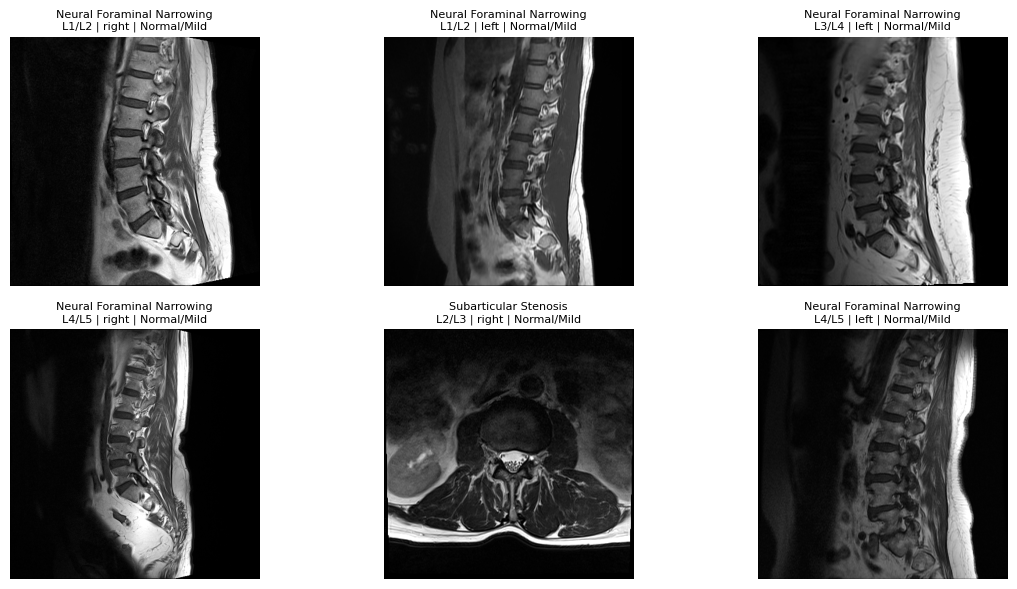

In [14]:
# VISUAL SANITY CHECK BEFORE NORMALIZATION
sample_df = norm_train_df.sample(min(6, len(norm_train_df)), random_state=42)

plt.figure(figsize=(12, 6))

for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
    img = read_dicom_array(row["img_path"])

    plt.subplot(2, 3, i)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(
        f"{row['base_condition']}\n"
        f"{row['level']} | {row['side']} | {row['severity']}",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

## 11. Image + metadata ResNet34 model

The CNN extracts image features.  
Metadata embeddings for `level`, `side`, and `series_description` are concatenated with image features before classification.

In [15]:
class ResNet34MetadataClassifier(nn.Module):
    def __init__(
        self,
        n_levels=5,
        n_sides=3,
        n_series=3,
        n_classes=N_CLASSES,
        pretrained=True,
        level_emb_dim=8,
        side_emb_dim=4,
        series_emb_dim=4,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ):
        super().__init__()

        if pretrained:
            weights = models.ResNet34_Weights.IMAGENET1K_V1
        else:
            weights = None

        self.backbone = models.resnet34(weights=weights)

        image_feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.level_emb = nn.Embedding(n_levels, level_emb_dim)
        self.side_emb = nn.Embedding(n_sides, side_emb_dim)
        self.series_emb = nn.Embedding(n_series, series_emb_dim)

        metadata_dim = level_emb_dim + side_emb_dim + series_emb_dim
        input_dim = image_feature_dim + metadata_dim

        # LayerNorm is used instead of BatchNorm1d because the final training batch
        # can occasionally contain one sample. BatchNorm1d crashes with batch size 1.
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),

            nn.Linear(hidden_dim // 2, n_classes),
        )

    def forward(self, images, metadata):
        image_features = self.backbone(images)

        level_features = self.level_emb(metadata["level"])
        side_features = self.side_emb(metadata["side"])
        series_features = self.series_emb(metadata["series"])

        metadata_features = torch.cat(
            [level_features, side_features, series_features],
            dim=1,
        )

        features = torch.cat(
            [image_features, metadata_features],
            dim=1,
        )

        logits = self.classifier(features)
        return logits


def make_optimizer(model, lr=LR, backbone_lr_multiplier=BACKBONE_LR_MULTIPLIER, weight_decay=WEIGHT_DECAY):
    """Use a lower learning rate for the pretrained image backbone and a higher one for the new metadata/head layers."""
    head_params = (
        list(model.level_emb.parameters())
        + list(model.side_emb.parameters())
        + list(model.series_emb.parameters())
        + list(model.classifier.parameters())
    )

    return torch.optim.AdamW(
        [
            {"params": model.backbone.parameters(), "lr": lr * backbone_lr_multiplier},
            {"params": head_params, "lr": lr},
        ],
        weight_decay=weight_decay,
    )


## 12. Loss, loaders, training, and evaluation utilities

In [16]:
def move_metadata_to_device(metadata, device):
    return {
        key: value.to(device, non_blocking=True)
        for key, value in metadata.items()
    }


def make_class_weighted_loss(
    train_df,
    device,
    moderate_weight_multiplier=MODERATE_WEIGHT_MULTIPLIER,
    severe_weight_multiplier=SEVERE_WEIGHT_MULTIPLIER,
    label_smoothing=LABEL_SMOOTHING,
):
    """
    Weighted cross-entropy for three-class medical classification.

    Base class weights are computed from the training split. The moderate and severe
    classes receive mild extra multipliers because under-calling pathology is more
    costly than over-calling it, especially for severe cases.
    """
    counts = np.bincount(train_df["target"].values, minlength=N_CLASSES).astype(np.float32)
    total = counts.sum()

    weights = np.zeros(N_CLASSES, dtype=np.float32)
    for cls in range(N_CLASSES):
        if counts[cls] > 0:
            weights[cls] = total / (N_CLASSES * counts[cls])
        else:
            weights[cls] = 0.0

    # Medical-priority adjustment:
    # class 0 = Normal/Mild, class 1 = Moderate, class 2 = Severe.
    if N_CLASSES > 1:
        weights[1] *= moderate_weight_multiplier
    if N_CLASSES > 2:
        weights[2] *= severe_weight_multiplier

    print("Class counts:", dict(zip(TARGET_NAMES, counts.astype(int))))
    print("Class weights:", dict(zip(TARGET_NAMES, weights.round(4))))

    weights = torch.tensor(weights, dtype=torch.float32).to(device)
    return nn.CrossEntropyLoss(weight=weights, label_smoothing=label_smoothing)


def make_weighted_sampler(train_df):
    """Optionally oversample minority-class examples during training batches."""
    targets = train_df["target"].values
    class_counts = np.bincount(targets, minlength=N_CLASSES).astype(np.float32)

    class_weights = np.zeros(N_CLASSES, dtype=np.float32)
    for cls in range(N_CLASSES):
        if class_counts[cls] > 0:
            class_weights[cls] = 1.0 / class_counts[cls]

    sample_weights = class_weights[targets]

    return WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )


def make_loaders(
    train_part,
    val_part,
    batch_size=BATCH_SIZE,
    use_weighted_sampler=USE_WEIGHTED_SAMPLER,
):
    train_dataset = LumbarMetadataClassificationDataset(
        train_part,
        transform=train_transform,
        augmentation_transform=train_augmentation,
        augment=USE_DATA_AUGMENTATION,
    )

    val_dataset = LumbarMetadataClassificationDataset(
        val_part,
        transform=val_transform,
        augment=False,
    )

    if use_weighted_sampler:
        train_sampler = make_weighted_sampler(train_part)
        shuffle_train = False
    else:
        train_sampler = None
        shuffle_train = True

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle_train,
        sampler=train_sampler,
        drop_last=True,  # avoids one-sample final batches and improves training stability
        **dataloader_worker_kwargs(NUM_WORKERS),
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        **dataloader_worker_kwargs(NUM_WORKERS),
    )

    return train_loader, val_loader


def make_test_loader(test_part, batch_size=BATCH_SIZE):
    test_dataset = LumbarMetadataClassificationDataset(
        test_part,
        transform=val_transform,
        augment=False,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        **dataloader_worker_kwargs(NUM_WORKERS),
    )

    return test_loader


In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    n_seen = 0
    all_preds = []
    all_labels = []

    for images, metadata, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        metadata = move_metadata_to_device(metadata, device)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images, metadata)
        loss = criterion(logits, labels)

        loss.backward()
        if GRAD_CLIP_NORM is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_seen += batch_size

        preds = logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / max(n_seen, 1)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return epoch_loss, epoch_acc, epoch_bal_acc, epoch_f1


@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    n_seen = 0
    all_preds = []
    all_labels = []
    all_probs = []

    for images, metadata, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        metadata = move_metadata_to_device(metadata, device)
        labels = labels.to(device, non_blocking=True)

        logits = model(images, metadata)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_seen += batch_size

        all_probs.extend(probs.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    all_probs = np.asarray(all_probs)
    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)

    epoch_loss = running_loss / max(n_seen, 1)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    severe_precision = precision_score(
        all_labels,
        all_preds,
        labels=[2],
        average="macro",
        zero_division=0,
    )

    severe_recall = recall_score(
        all_labels,
        all_preds,
        labels=[2],
        average="macro",
        zero_division=0,
    )

    severe_f1 = f1_score(
        all_labels,
        all_preds,
        labels=[2],
        average="macro",
        zero_division=0,
    )

    # Binary medical view: any pathological severity = Moderate or Severe.
    y_true_pathological = (all_labels >= 1).astype(int)
    y_pred_pathological = (all_preds >= 1).astype(int)

    pathological_precision = precision_score(
        y_true_pathological,
        y_pred_pathological,
        zero_division=0,
    )

    pathological_recall = recall_score(
        y_true_pathological,
        y_pred_pathological,
        zero_division=0,
    )

    pathological_f1 = f1_score(
        y_true_pathological,
        y_pred_pathological,
        zero_division=0,
    )

    try:
        epoch_logloss = log_loss(all_labels, all_probs, labels=list(range(N_CLASSES)))
    except ValueError:
        epoch_logloss = np.nan

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "balanced_accuracy": epoch_bal_acc,
        "macro_f1": epoch_f1,
        "severe_precision": severe_precision,
        "severe_recall": severe_recall,
        "severe_f1": severe_f1,
        "pathological_precision": pathological_precision,
        "pathological_recall": pathological_recall,
        "pathological_f1": pathological_f1,
        "log_loss": epoch_logloss,
        "y_true": all_labels,
        "y_pred": all_preds,
        "y_prob": all_probs,
    }


In [18]:
def fit_model(
    model_name,
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs=EPOCHS,
    min_epochs=MIN_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_checkpoint_score = -np.inf
    best_early_stop_score = -np.inf
    best_epoch = 0
    epochs_without_early_stop_improvement = 0

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_balanced_accuracy": [],
        "train_macro_f1": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_balanced_accuracy": [],
        "val_macro_f1": [],
        "val_severe_precision": [],
        "val_severe_recall": [],
        "val_severe_f1": [],
        "val_pathological_precision": [],
        "val_pathological_recall": [],
        "val_pathological_f1": [],
        "val_log_loss": [],
        "val_checkpoint_score": [],
        "val_early_stop_score": [],
    }

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")

        train_loss, train_acc, train_bal_acc, train_f1 = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
        )

        val_metrics = evaluate_one_epoch(
            model,
            val_loader,
            criterion,
            device,
        )

        if scheduler is not None:
            scheduler.step(val_metrics["loss"])

        # Checkpointing is medically oriented: it prioritizes severe recall,
        # but still rewards severe F1, macro F1 and balanced accuracy.
        checkpoint_score = (
            0.35 * val_metrics["severe_recall"]
            + 0.25 * val_metrics["severe_f1"]
            + 0.20 * val_metrics["macro_f1"]
            + 0.20 * val_metrics["balanced_accuracy"]
        )

        # Early stopping uses a more general validation-progress signal.
        # This avoids stopping only because severe recall temporarily decreased
        # while F1/balanced accuracy continue to improve.
        early_stop_score = (
            0.50 * val_metrics["macro_f1"]
            + 0.50 * val_metrics["balanced_accuracy"]
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["train_balanced_accuracy"].append(train_bal_acc)
        history["train_macro_f1"].append(train_f1)

        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_balanced_accuracy"].append(val_metrics["balanced_accuracy"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["val_severe_precision"].append(val_metrics["severe_precision"])
        history["val_severe_recall"].append(val_metrics["severe_recall"])
        history["val_severe_f1"].append(val_metrics["severe_f1"])
        history["val_pathological_precision"].append(val_metrics["pathological_precision"])
        history["val_pathological_recall"].append(val_metrics["pathological_recall"])
        history["val_pathological_f1"].append(val_metrics["pathological_f1"])
        history["val_log_loss"].append(val_metrics["log_loss"])
        history["val_checkpoint_score"].append(checkpoint_score)
        history["val_early_stop_score"].append(early_stop_score)

        print(
            f"Train loss: {train_loss:.4f} | "
            f"Train acc: {train_acc:.4f} | "
            f"Train bal acc: {train_bal_acc:.4f} | "
            f"Train macro F1: {train_f1:.4f}"
        )

        print(
            f"Val loss: {val_metrics['loss']:.4f} | "
            f"Val acc: {val_metrics['accuracy']:.4f} | "
            f"Val bal acc: {val_metrics['balanced_accuracy']:.4f} | "
            f"Val macro F1: {val_metrics['macro_f1']:.4f} | "
            f"Val severe precision: {val_metrics['severe_precision']:.4f} | "
            f"Val severe recall: {val_metrics['severe_recall']:.4f} | "
            f"Val severe F1: {val_metrics['severe_f1']:.4f} | "
            f"Checkpoint score: {checkpoint_score:.4f} | "
            f"Early-stop score: {early_stop_score:.4f}"
        )

        checkpoint_improved = checkpoint_score > best_checkpoint_score + min_delta
        early_stop_improved = early_stop_score > best_early_stop_score + min_delta

        if checkpoint_improved:
            best_checkpoint_score = checkpoint_score
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

            save_path = OUTPUT_DIR / f"{model_name}_best.pt"
            torch.save(best_model_wts, save_path)
            print(f"Saved best model: {save_path}")

        if early_stop_improved:
            best_early_stop_score = early_stop_score
            epochs_without_early_stop_improvement = 0
        else:
            epochs_without_early_stop_improvement += 1
            print(
                f"No early-stopping improvement for "
                f"{epochs_without_early_stop_improvement}/{patience} epochs."
            )

        if (epoch + 1) >= min_epochs and epochs_without_early_stop_improvement >= patience:
            print(
                f"Early stopping at epoch {epoch + 1}. "
                f"Best checkpoint epoch was {best_epoch} with checkpoint score {best_checkpoint_score:.4f}."
            )
            break

    model.load_state_dict(best_model_wts)

    history_df = pd.DataFrame(history)
    history_df.insert(0, "epoch", range(1, len(history_df) + 1))
    history_df.to_csv(OUTPUT_DIR / f"{model_name}_history.csv", index=False)

    return model, history_df


## 13. Plot helpers

In [21]:
# ============================================================
# EVALUATION HELPERS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize


def plot_history(history_df, title="Training history"):
    epochs = history_df["epoch"]

    plt.figure(figsize=(20, 4))

    plt.subplot(1, 4, 1)
    plt.plot(epochs, history_df["train_loss"], label="train")
    plt.plot(epochs, history_df["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 4, 2)
    plt.plot(epochs, history_df["train_balanced_accuracy"], label="train")
    plt.plot(epochs, history_df["val_balanced_accuracy"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Balanced accuracy")
    plt.title("Balanced accuracy")
    plt.legend()

    plt.subplot(1, 4, 3)
    plt.plot(epochs, history_df["train_macro_f1"], label="train")
    plt.plot(epochs, history_df["val_macro_f1"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")
    plt.title("Macro F1")
    plt.legend()

    plt.subplot(1, 4, 4)
    plt.plot(epochs, history_df["val_severe_recall"], label="severe recall")
    plt.plot(epochs, history_df["val_severe_precision"], label="severe precision")
    plt.plot(epochs, history_df["val_pathological_recall"], label="moderate/severe recall")
    plt.plot(epochs, history_df["val_checkpoint_score"], label="checkpoint score")
    plt.plot(epochs, history_df["val_early_stop_score"], label="early-stop score")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Medical-priority metrics")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def load_best_model(model_name):
    model = ResNet34MetadataClassifier(
        n_levels=len(LEVEL_TO_ID),
        n_sides=len(SIDE_TO_ID),
        n_series=len(SERIES_TO_ID),
        n_classes=N_CLASSES,
        pretrained=PRETRAINED,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ).to(DEVICE)

    model_path = OUTPUT_DIR / f"{model_name}_best.pt"
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    return model


def compute_ovr_auc_and_accuracy(y_true, y_prob, class_names):
    """
    Computes class-wise one-vs-rest AUC and one-vs-rest accuracy.

    acc_ovr for a class means:
    class vs all other classes accuracy = (TP + TN) / all samples
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    n_classes = len(class_names)
    labels = list(range(n_classes))
    y_true_bin = label_binarize(y_true, classes=labels)

    auc_by_class = {}
    acc_ovr_by_class = {}

    for class_idx, class_name in enumerate(class_names):
        y_true_class = y_true_bin[:, class_idx]
        y_prob_class = y_prob[:, class_idx]

        # One-vs-rest prediction from predicted class probabilities
        y_pred_class = (np.argmax(y_prob, axis=1) == class_idx).astype(int)

        acc_ovr_by_class[class_name] = (y_true_class == y_pred_class).mean()

        if len(np.unique(y_true_class)) < 2:
            auc_by_class[class_name] = np.nan
        else:
            fpr, tpr, _ = roc_curve(y_true_class, y_prob_class)
            auc_by_class[class_name] = auc(fpr, tpr)

    try:
        macro_auc = roc_auc_score(
            y_true_bin,
            y_prob,
            average="macro",
            multi_class="ovr",
        )
    except ValueError:
        macro_auc = np.nan

    try:
        weighted_auc = roc_auc_score(
            y_true_bin,
            y_prob,
            average="weighted",
            multi_class="ovr",
        )
    except ValueError:
        weighted_auc = np.nan

    return auc_by_class, acc_ovr_by_class, macro_auc, weighted_auc


def make_report_table(y_true, y_pred, y_prob, class_names=TARGET_NAMES):
    labels = list(range(len(class_names)))

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=class_names,
        zero_division=0,
        output_dict=True,
    )

    report_table = pd.DataFrame(report_dict).T.reset_index()
    report_table = report_table.rename(columns={"index": "class"})

    auc_by_class, acc_ovr_by_class, macro_auc, weighted_auc = compute_ovr_auc_and_accuracy(
        y_true,
        y_prob,
        class_names,
    )

    report_table["acc_ovr"] = np.nan
    report_table["auc_ovr"] = np.nan

    for class_name in class_names:
        report_table.loc[report_table["class"] == class_name, "acc_ovr"] = acc_ovr_by_class[class_name]
        report_table.loc[report_table["class"] == class_name, "auc_ovr"] = auc_by_class[class_name]

    return report_table, macro_auc, weighted_auc


def plot_confusion_and_roc_side_by_side(
    y_true,
    y_pred,
    y_prob,
    class_names=TARGET_NAMES,
    title_prefix="Test",
    save_path=None,
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    n_classes = len(class_names)
    labels = list(range(n_classes))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    y_true_bin = label_binarize(y_true, classes=labels)

    auc_by_class, _, macro_auc, weighted_auc = compute_ovr_auc_and_accuracy(
        y_true,
        y_prob,
        class_names,
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ----------------------------
    # Confusion matrix
    # ----------------------------
    ax = axes[0]
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(f"{title_prefix}\nConfusion matrix")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    tick_marks = np.arange(n_classes)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(class_names)

    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")

    # ----------------------------
    # ROC curves
    # ----------------------------
    ax = axes[1]

    for class_idx, class_name in enumerate(class_names):
        y_true_class = y_true_bin[:, class_idx]
        y_prob_class = y_prob[:, class_idx]

        if len(np.unique(y_true_class)) < 2:
            continue

        fpr, tpr, _ = roc_curve(y_true_class, y_prob_class)

        ax.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{class_name} AUC={auc_by_class[class_name]:.3f}",
        )

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Chance")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(
        f"{title_prefix}\nROC / AUC | Macro={macro_auc:.3f}, Weighted={weighted_auc:.3f}"
    )
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

    return macro_auc, weighted_auc

## 14. Train the three classifiers

This trains:

- `spinal_canal_stenosis`
- `neural_foraminal_narrowing`
- `subarticular_stenosis`


Training model: spinal_canal_stenosis
Class counts: {'Normal/Mild': np.int64(5964), 'Moderate': np.int64(513), 'Severe': np.int64(343)}
Class weights: {'Normal/Mild': np.float32(0.3812), 'Moderate': np.float32(4.8746), 'Severe': np.float32(8.6161)}

Epoch 1/50


  0%|          | 0/213 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

Train loss: 0.9890 | Train acc: 0.5910 | Train bal acc: 0.4570 | Train macro F1: 0.3635
Val loss: 0.8058 | Val acc: 0.7127 | Val bal acc: 0.5681 | Val macro F1: 0.4497 | Val severe precision: 0.1980 | Val severe recall: 0.6190 | Val severe F1: 0.3000 | Checkpoint score: 0.4952 | Early-stop score: 0.5089
Saved best model: models/models_baseline_three_class_medical_oriented/spinal_canal_stenosis_best.pt

Epoch 2/50


  0%|          | 0/213 [00:00<?, ?it/s]

...

  0%|          | 0/46 [00:00<?, ?it/s]

Train loss: 0.3814 | Train acc: 0.8832 | Train bal acc: 0.8517 | Train macro F1: 0.7305
Val loss: 1.1489 | Val acc: 0.8427 | Val bal acc: 0.6003 | Val macro F1: 0.5597 | Val severe precision: 0.3793 | Val severe recall: 0.5238 | Val severe F1: 0.4400 | Checkpoint score: 0.5253 | Early-stop score: 0.5800
No early-stopping improvement for 9/10 epochs.

Epoch 21/50


  0%|          | 0/213 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

Train loss: 0.3910 | Train acc: 0.8801 | Train bal acc: 0.8503 | Train macro F1: 0.7284
Val loss: 1.1288 | Val acc: 0.8283 | Val bal acc: 0.5980 | Val macro F1: 0.5536 | Val severe precision: 0.3816 | Val severe recall: 0.4603 | Val severe F1: 0.4173 | Checkpoint score: 0.4957 | Early-stop score: 0.5758
No early-stopping improvement for 10/10 epochs.
Early stopping at epoch 21. Best checkpoint epoch was 7 with checkpoint score 0.5541.


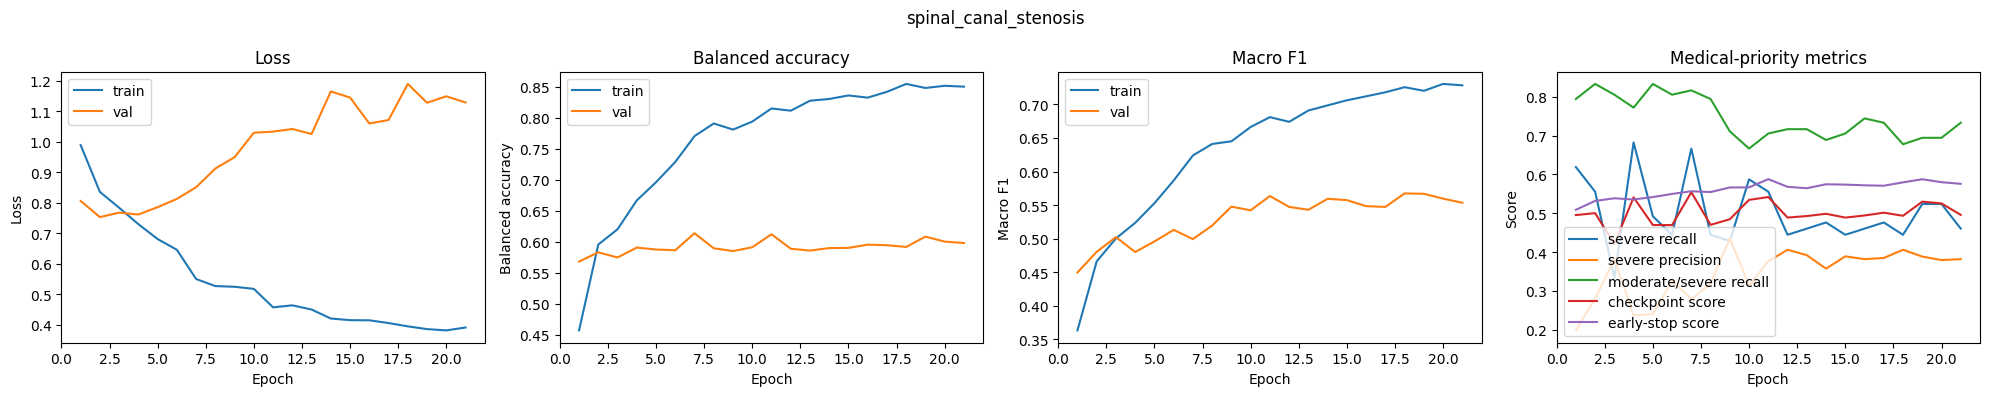


Training model: neural_foraminal_narrowing
Class counts: {'Normal/Mild': np.int64(10800), 'Moderate': np.int64(2462), 'Severe': np.int64(517)}
Class weights: {'Normal/Mild': np.float32(0.4253), 'Moderate': np.float32(2.0521), 'Severe': np.float32(11.5491)}

Epoch 1/50


  0%|          | 0/430 [00:00<?, ?it/s]

  0%|          | 0/93 [00:00<?, ?it/s]

Train loss: 0.7691 | Train acc: 0.7194 | Train bal acc: 0.6432 | Train macro F1: 0.5675
Val loss: 0.8372 | Val acc: 0.7208 | Val bal acc: 0.6084 | Val macro F1: 0.5358 | Val severe precision: 0.2613 | Val severe recall: 0.5912 | Val severe F1: 0.3624 | Checkpoint score: 0.5264 | Early-stop score: 0.5721
Saved best model: models/models_baseline_three_class_medical_oriented/neural_foraminal_narrowing_best.pt

Epoch 5/50


  0%|          | 0/430 [00:00<?, ?it/s]

...

  0%|          | 0/90 [00:00<?, ?it/s]

Train loss: 0.3191 | Train acc: 0.8612 | Train bal acc: 0.8739 | Train macro F1: 0.8221
Val loss: 1.2153 | Val acc: 0.7392 | Val bal acc: 0.6626 | Val macro F1: 0.6366 | Val severe precision: 0.5348 | Val severe recall: 0.6168 | Val severe F1: 0.5729 | Checkpoint score: 0.6189 | Early-stop score: 0.6496
No early-stopping improvement for 11/10 epochs.

Epoch 15/50


  0%|          | 0/420 [00:00<?, ?it/s]

  0%|          | 0/90 [00:00<?, ?it/s]

Train loss: 0.3075 | Train acc: 0.8664 | Train bal acc: 0.8809 | Train macro F1: 0.8289
Val loss: 1.2971 | Val acc: 0.7549 | Val bal acc: 0.6613 | Val macro F1: 0.6474 | Val severe precision: 0.5735 | Val severe recall: 0.5693 | Val severe F1: 0.5714 | Checkpoint score: 0.6039 | Early-stop score: 0.6544
No early-stopping improvement for 12/10 epochs.
Early stopping at epoch 15. Best checkpoint epoch was 2 with checkpoint score 0.6756.


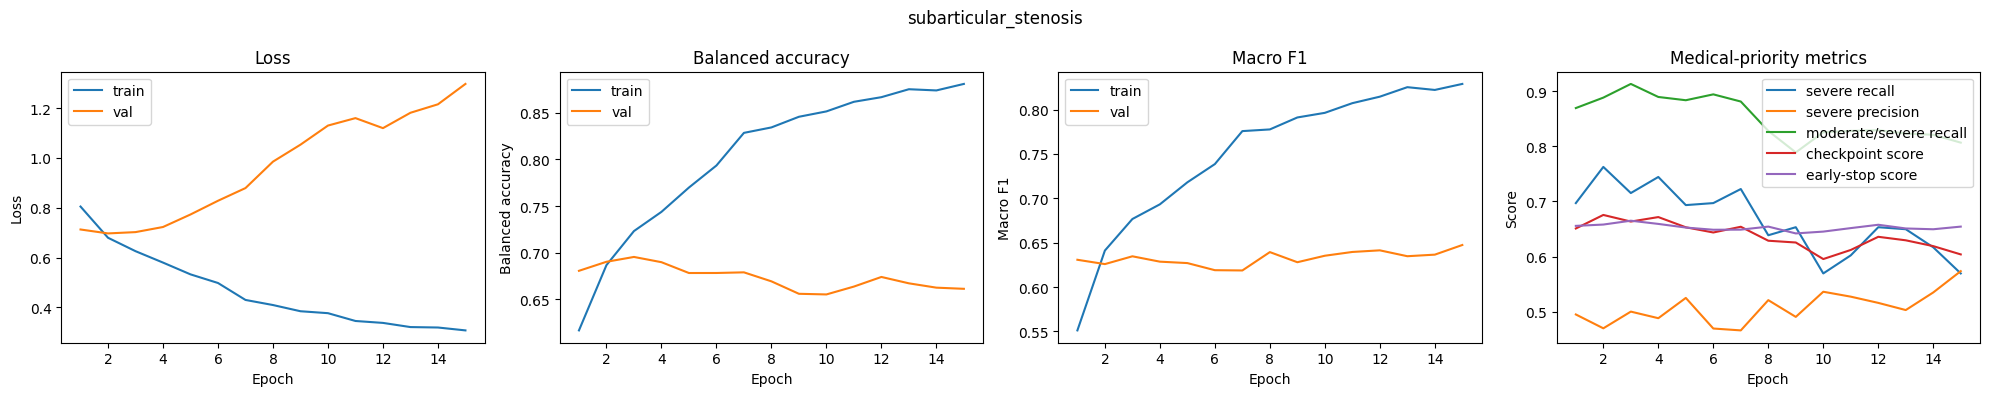

In [19]:
import gc

trained_models = {}
histories = {}

for model_name in MODEL_CONFIGS.keys():
    print("\n" + "=" * 80)
    print(f"Training model: {model_name}")
    print("=" * 80)

    # Explicitly release old loaders before creating new ones.
    try:
        del train_loader
        del val_loader
    except NameError:
        pass
    gc.collect()

    train_part = model_dfs[model_name]["train"]
    val_part = model_dfs[model_name]["val"]

    if len(train_part) == 0 or len(val_part) == 0:
        print(f"Skipping {model_name}: empty train or validation set.")
        continue

    train_loader, val_loader = make_loaders(
        train_part,
        val_part,
        batch_size=BATCH_SIZE,
        use_weighted_sampler=USE_WEIGHTED_SAMPLER,
    )

    model = ResNet34MetadataClassifier(
        n_levels=len(LEVEL_TO_ID),
        n_sides=len(SIDE_TO_ID),
        n_series=len(SERIES_TO_ID),
        n_classes=N_CLASSES,
        pretrained=PRETRAINED,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ).to(DEVICE)

    criterion = make_class_weighted_loss(train_part, DEVICE)
    optimizer = make_optimizer(model)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    model, history_df = fit_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=DEVICE,
        epochs=EPOCHS,
        min_epochs=MIN_EPOCHS,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
    )

    trained_models[model_name] = model
    histories[model_name] = history_df

    plot_history(history_df, title=model_name)


## 15. Test evaluation


Testing model: spinal_canal_stenosis
Class counts: {'Normal/Mild': np.int64(5964), 'Moderate': np.int64(513), 'Severe': np.int64(343)}
Class weights: {'Normal/Mild': np.float32(0.3812), 'Moderate': np.float32(4.8746), 'Severe': np.float32(8.6161)}


  0%|          | 0/46 [00:00<?, ?it/s]

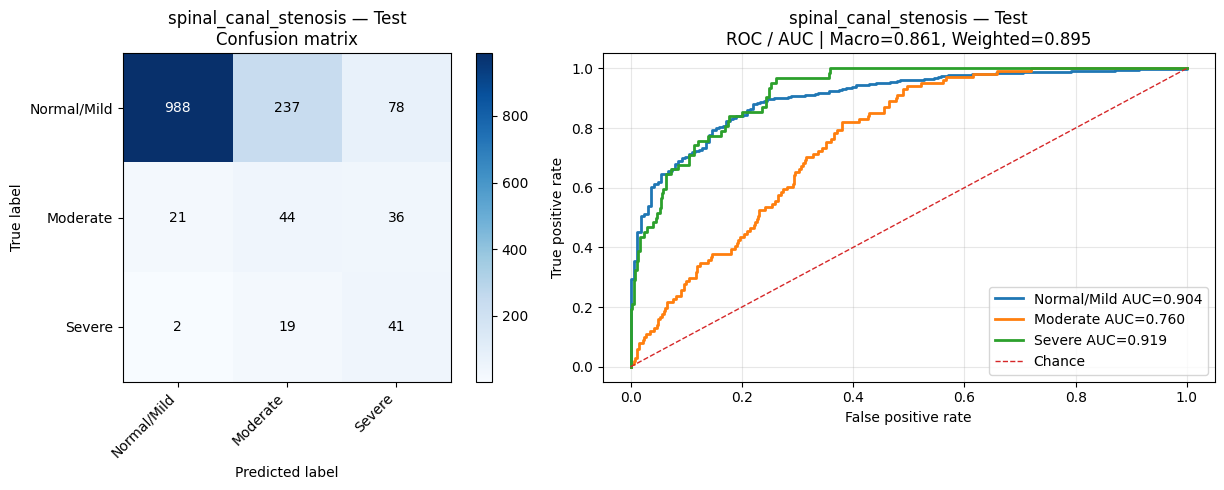

spinal_canal_stenosis — classification report


,class,precision,recall,f1-score,support,acc_ovr,auc_ovr
0,Normal/Mild,0.977250,0.758250,0.853933,1303.000000,0.769441,0.903856
1,Moderate,0.146667,0.435644,0.219451,101.000000,0.786494,0.759838
2,Severe,0.264516,0.661290,0.377880,62.000000,0.907913,0.919263
3,accuracy,0.731924,0.731924,0.731924,0.731924,NaN,NaN
4,macro avg,0.462811,0.618395,0.483755,1466.000000,NaN,NaN
5,weighted avg,0.889884,0.731924,0.790087,1466.000000,NaN,NaN



Testing model: neural_foraminal_narrowing
Class counts: {'Normal/Mild': np.int64(10800), 'Moderate': np.int64(2462), 'Severe': np.int64(517)}
Class weights: {'Normal/Mild': np.float32(0.4253), 'Moderate': np.float32(2.0521), 'Severe': np.float32(11.5491)}


  0%|          | 0/93 [00:00<?, ?it/s]

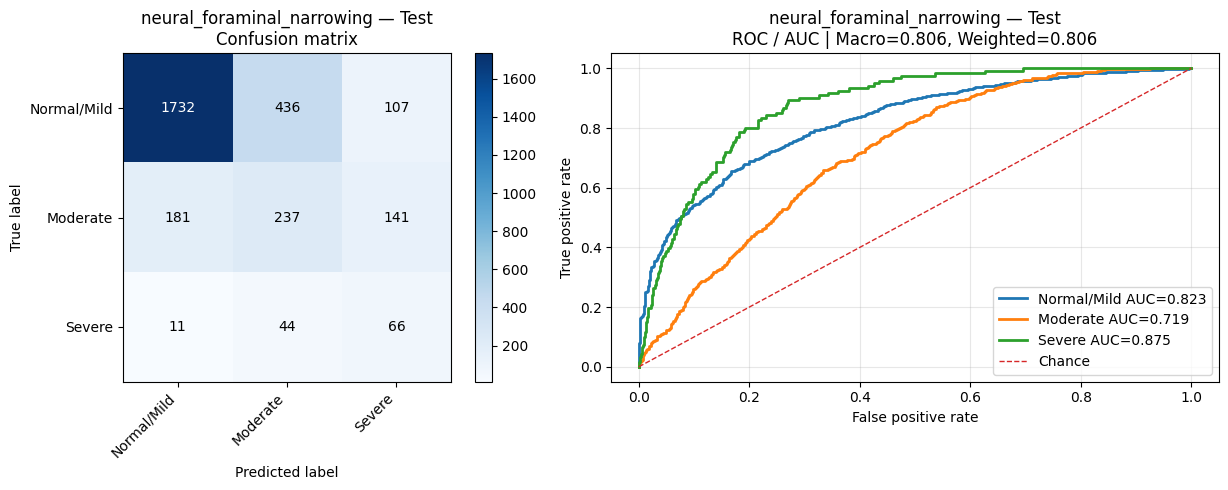

neural_foraminal_narrowing — classification report


,class,precision,recall,f1-score,support,acc_ovr,auc_ovr
0,Normal/Mild,0.900208,0.761319,0.824958,2275.000000,0.751269,0.823223
1,Moderate,0.330544,0.423971,0.371473,559.000000,0.728596,0.718934
2,Severe,0.210191,0.545455,0.303448,121.000000,0.897462,0.875059
3,accuracy,0.688663,0.688663,0.688663,0.688663,NaN,NaN
4,macro avg,0.480314,0.576915,0.499960,2955.000000,NaN,NaN
5,weighted avg,0.764190,0.688663,0.717818,2955.000000,NaN,NaN



Testing model: subarticular_stenosis
Class counts: {'Normal/Mild': np.int64(9601), 'Moderate': np.int64(2549), 'Severe': np.int64(1291)}
Class weights: {'Normal/Mild': np.float32(0.4667), 'Moderate': np.float32(1.9335), 'Severe': np.float32(4.5116)}


  0%|          | 0/91 [00:00<?, ?it/s]

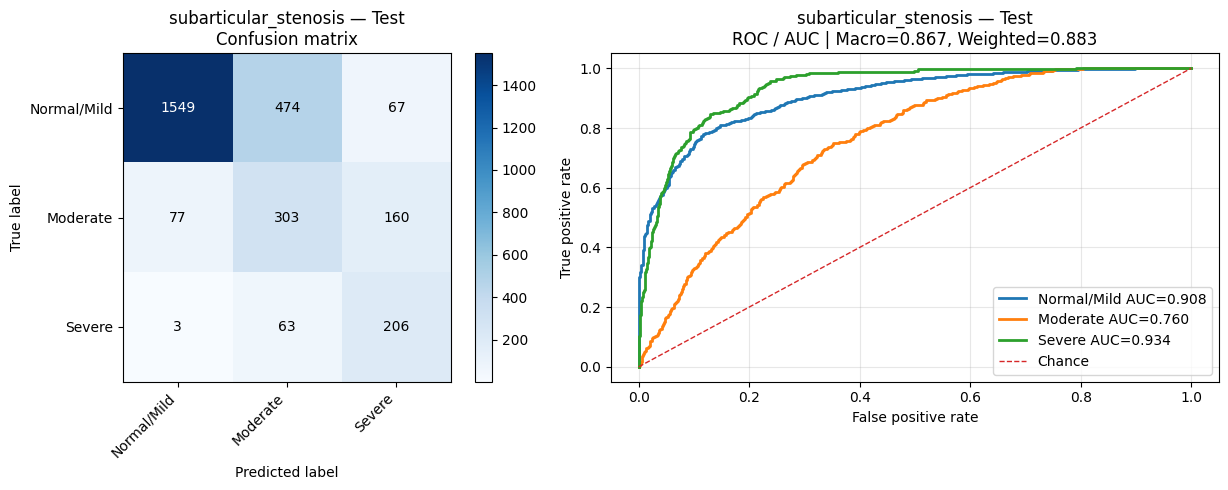

subarticular_stenosis — classification report


,class,precision,recall,f1-score,support,acc_ovr,auc_ovr
0,Normal/Mild,0.950890,0.741148,0.833020,2090.000000,0.786010,0.907666
1,Moderate,0.360714,0.561111,0.439130,540.000000,0.733287,0.759917
2,Severe,0.475751,0.757353,0.584397,272.000000,0.899035,0.933924
3,accuracy,0.709166,0.709166,0.709166,0.709166,NaN,NaN
4,macro avg,0.595785,0.686537,0.618849,2902.000000,NaN,NaN
5,weighted avg,0.796537,0.709166,0.736422,2902.000000,NaN,NaN


,model,input,pretrained,use_weighted_sampler,moderate_weight_multiplier,severe_weight_multiplier,label_smoothing,hidden_dim,dropout,backbone_lr_multiplier,...,test_pathological_recall,test_pathological_f1,n_test_rows,n_test_studies,test_acc_normal_mild_ovr,test_auc_normal_mild_ovr,test_acc_moderate_ovr,test_auc_moderate_ovr,test_acc_severe_ovr,test_auc_severe_ovr
0,spinal_canal_stenosis,full_image_grayscale_repeated_3ch_plus_metadata,True,False,1.1,1.3,0.0,512,0.15,0.1,...,0.858896,0.453074,1466,297,0.769441,0.903856,0.786494,0.759838,0.907913,0.919263
1,neural_foraminal_narrowing,full_image_grayscale_repeated_3ch_plus_metadata,True,False,1.1,1.3,0.0,512,0.15,0.1,...,0.717647,0.570427,2955,296,0.751269,0.823223,0.728596,0.718934,0.897462,0.875059
2,subarticular_stenosis,full_image_grayscale_repeated_3ch_plus_metadata,True,False,1.1,1.3,0.0,512,0.15,0.1,...,0.901478,0.702158,2902,297,0.786010,0.907666,0.733287,0.759917,0.899035,0.933924


Saved: models/models_baseline_three_class_medical_oriented/test_results_medical_oriented_pretrained.csv


In [22]:
# ============================================================
# TEST EVALUATION
# ============================================================

test_results = []

for model_name in MODEL_CONFIGS.keys():
    print("\n" + "=" * 80)
    print(f"Testing model: {model_name}")
    print("=" * 80)

    test_part = model_dfs[model_name]["test"]

    if len(test_part) == 0:
        print(f"Skipping {model_name}: empty test set.")
        continue

    model = load_best_model(model_name)
    test_loader = make_test_loader(test_part, batch_size=BATCH_SIZE)

    # Use train split for loss weights; metrics are the primary comparison.
    criterion = make_class_weighted_loss(model_dfs[model_name]["train"], DEVICE)

    metrics = evaluate_one_epoch(
        model,
        test_loader,
        criterion,
        DEVICE,
    )

    # ------------------------------------------------------------
    # Combined plot: confusion matrix + ROC/AUC
    # ------------------------------------------------------------
    combined_plot_path = OUTPUT_DIR / f"{model_name}_test_confusion_and_roc.png"

    macro_auc, weighted_auc = plot_confusion_and_roc_side_by_side(
        metrics["y_true"],
        metrics["y_pred"],
        metrics["y_prob"],
        class_names=TARGET_NAMES,
        title_prefix=f"{model_name} — Test",
        save_path=combined_plot_path,
    )

    # ------------------------------------------------------------
    # One report table: precision, recall, f1, support, acc_ovr, auc_ovr
    # ------------------------------------------------------------
    report_table, macro_auc, weighted_auc = make_report_table(
        metrics["y_true"],
        metrics["y_pred"],
        metrics["y_prob"],
        class_names=TARGET_NAMES,
    )

    print(f"{model_name} — classification report")
    display(report_table)

    row = {
        "model": model_name,
        "input": "full_image_grayscale_repeated_3ch_plus_metadata",
        "pretrained": PRETRAINED,
        "use_weighted_sampler": USE_WEIGHTED_SAMPLER,
        "moderate_weight_multiplier": MODERATE_WEIGHT_MULTIPLIER,
        "severe_weight_multiplier": SEVERE_WEIGHT_MULTIPLIER,
        "label_smoothing": LABEL_SMOOTHING,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "backbone_lr_multiplier": BACKBONE_LR_MULTIPLIER,
        "min_epochs": MIN_EPOCHS,
        "patience": PATIENCE,
        "test_loss": metrics["loss"],
        "test_log_loss": metrics["log_loss"],
        "test_accuracy": metrics["accuracy"],
        "test_balanced_accuracy": metrics["balanced_accuracy"],
        "test_macro_f1": metrics["macro_f1"],
        "test_macro_auc_ovr": macro_auc,
        "test_weighted_auc_ovr": weighted_auc,
        "test_severe_precision": metrics["severe_precision"],
        "test_severe_recall": metrics["severe_recall"],
        "test_severe_f1": metrics["severe_f1"],
        "test_pathological_precision": metrics["pathological_precision"],
        "test_pathological_recall": metrics["pathological_recall"],
        "test_pathological_f1": metrics["pathological_f1"],
        "n_test_rows": len(test_part),
        "n_test_studies": test_part["study_id"].nunique(),
    }

    # Add class-wise AUC and one-vs-rest accuracy into the main results table.
    for _, report_row in report_table.iterrows():
        class_name = report_row["class"]

        if class_name not in TARGET_NAMES:
            continue

        safe_class_name = (
            class_name
            .lower()
            .replace("/", "_")
            .replace(" ", "_")
            .replace("-", "_")
        )

        row[f"test_acc_{safe_class_name}_ovr"] = report_row["acc_ovr"]
        row[f"test_auc_{safe_class_name}_ovr"] = report_row["auc_ovr"]

    test_results.append(row)

results_table = pd.DataFrame(test_results)
display(results_table)

suffix = "pretrained" if PRETRAINED else "scratch"
results_path = OUTPUT_DIR / f"test_results_medical_oriented_{suffix}.csv"

results_table.to_csv(results_path, index=False)

print("Saved:", results_path)